## Demonstration of Support Vector Machines (SVMs)This notebook demonstrates loading the Mushroom dataset, preprocessing, handling missing values, classification using Support Vector Machines (SVMs), and visualizing decision boundaries on a concentric-circles dataset using both linear and non-linear SVMs.

Features: All 22 features are categorical, encoded as single-letter codes. The target is `class` (edible = `e`, poisonous = `p`).
1. cap-shape: bell=b, conical=c, convex=x, flat=f, knobbed=k, sunken=s
2. cap-surface: fibrous=f, grooves=g, scaly=y, smooth=s
3. cap-color: brown=n, buff=b, cinnamon=c, gray=g, green=r, pink=p, purple=u, red=e, white=w, yellow=y
4. bruises?: bruises=t, no=f
5. odor: almond=a, anise=l, creosote=c, fishy=y, foul=f, musty=m, none=n, pungent=p, spicy=s
6. gill-attachment: attached=a, descending=d, free=f, notched=n
7. gill-spacing: close=c, crowded=w, distant=d
8. gill-size: broad=b, narrow=n
9. gill-color: black=k, brown=n, buff=b, chocolate=h, gray=g, green=r, orange=o, pink=p, purple=u, red=e, white=w, yellow=y
10. stalk-shape: enlarging=e, tapering=t
11. stalk-root: bulbous=b, club=c, cup=u, equal=e, rhizomorphs=z, rooted=r, **missing=?**
12. stalk-surface-above-ring: fibrous=f, scaly=y, silky=k, smooth=s
13. stalk-surface-below-ring: fibrous=f, scaly=y, silky=k, smooth=s
14. stalk-color-above-ring: brown=n, buff=b, cinnamon=c, gray=g, orange=o, pink=p, red=e, white=w, yellow=y
15. stalk-color-below-ring: brown=n, buff=b, cinnamon=c, gray=g, orange=o, pink=p, red=e, white=w, yellow=y
16. veil-type: partial=p, universal=u17. veil-color: brown=n, orange=o, white=w, yellow=y
18. ring-number: none=n, one=o, two=t
19. ring-type: cobwebby=c, evanescent=e, flaring=f, large=l, none=n, pendant=p, sheathing=s, zone=z
20. spore-print-color: black=k, brown=n, buff=b, chocolate=h, green=r, orange=o, purple=u, white=w, yellow=y
21. population: abundant=a, clustered=c, numerous=n, scattered=s, several=v, solitary=y
22. habitat: grasses=g, leaves=l, meadows=m, paths=p, urban=u, waste=w, woods=d
23. class (target, predicted attribute): edible=e, poisonous=p

## 1. Load the Mushroom Dataset

In [ ]:
import pandas as pd
import urllib.request

# Load the dataset (ARFF format mirror of the UCI Mushroom dataset)
url = "https://raw.githubusercontent.com/renatopp/arff-datasets/master/classification/mushroom.arff"
raw = urllib.request.urlopen(url).read().decode('utf-8')
lines = raw.splitlines()

# parse feature/target names from the @attribute declarations
columns = [l.split("'")[1] for l in lines if l.lower().startswith('@attribute')]

# parse the actual data rows after the @data marker
data_start = next(i for i, l in enumerate(lines) if l.strip().lower() == '@data') + 1
data_lines = [l for l in lines[data_start:] if l.strip() and not l.strip().startswith('%')]
rows = [[v.strip().strip("'") for v in line.split(',')] for line in data_lines]

df = pd.DataFrame(rows, columns=columns)
df.head()

,cap-shape,cap-surface,cap-color,bruises?,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,class
0,x,s,n,t,p,f,c,n,k,e,...,w,w,p,w,o,p,k,s,u,p
1,x,s,y,t,a,f,c,b,k,e,...,w,w,p,w,o,p,n,n,g,e
2,b,s,w,t,l,f,c,b,n,e,...,w,w,p,w,o,p,n,n,m,e
3,x,y,w,t,p,f,c,n,n,e,...,w,w,p,w,o,p,k,s,u,p
4,x,s,g,f,n,f,w,b,k,t,...,w,w,p,w,o,e,n,a,g,e


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   cap-shape                 8124 non-null   object
 1   cap-surface               8124 non-null   object
 2   cap-color                 8124 non-null   object
 3   bruises?                  8124 non-null   object
 4   odor                      8124 non-null   object
 5   gill-attachment           8124 non-null   object
 6   gill-spacing              8124 non-null   object
 7   gill-size                 8124 non-null   object
 8   gill-color                8124 non-null   object
 9   stalk-shape               8124 non-null   object
 10  stalk-root                8124 non-null   object
 11  stalk-surface-above-ring  8124 non-null   object
 12  stalk-surface-below-ring  8124 non-null   object
 13  stalk-color-above-ring    8124 non-null   object
 14  stalk-color-below-ring  

In [ ]:
# Display all rows of the dataframe
pd.set_option('display.max_rows', None)
display(df.head)

<bound method NDFrame.head of      cap-shape cap-surface cap-color bruises? odor gill-attachment  \
0            x           s         n        t    p               f   
1            x           s         y        t    a               f   
2            b           s         w        t    l               f   
3            x           y         w        t    p               f   
4            x           s         g        f    n               f   
5            x           y         y        t    a               f   
6            b           s         w        t    a               f   
7            b           y         w        t    l               f   
8            x           y         w        t    p               f   
9            b           s         y        t    a               f   
10           x           y         y        t    l               f   
11           x           y         y        t    a               f   
12           b           s         y        t    a               f   
13           x           y         w        t    p               f   
14           x           f         n        f    n               f   
15           s           f         g        f    n               f   
16           f           f         w        f    n               f   
17           x           s         n        t    p               f   
18           x           y         w        t    p               f   
19           x           s         n        t    p               f   
20           b           s         y        t    a               f   
21           x           y         n        t    p               f   
22           b           y         y        t    l               f   
23           b           y         w        t    a               f   
24           b           s         w        t    l               f   
25           f           s         w        t    p               f   
26           x           y         y        t    a               f   
27           x           y         w        t    l               f   
28           f           f         n        f    n               f   
29           x           s         y        t    a               f   
30           b           s         y        t    l               f   
31           x           y         w        t    p               f   
32           x           y         y        t    l               f   
33           x           y         n        t    l               f   
34           b           y         y        t    l               f   
35           x           f         y        t    l               f   
36           s           f         g        f    n               f   
37           x           y         n        t    p               f   
38           x           f         y        t    a               f   
39           b           s         y        t    l               f   
40           b           y         y        t    a               f   
41           x           y         y        t    l               f   
42           x           f         n        f    n               f   
43           x           y         w        t    p               f   
44           x           s         y        t    a               f   
45           x           y         w        t    a               f   
46           x           y         y        t    l               f   
47           x           s         w        t    l               f   
48           x           y         y        t    l               f   
49           f           y         y        t    l               f   
50           x           y         n        t    a               f   
51           x           s         w        t    l               f   
52           b           s         w        t    l               f   
53           x           y         n        t    p               f   
54           x           s         w        t    p               f   
55           b           y         y        t    a

## 2. Handle Missing Values and Remove Duplicates

In [ ]:
# Check for missing values (marked by '?')
df.replace('?', pd.NA, inplace=True)

df.isnull().sum()[df.isnull().sum() > 0]

,0
stalk-root,2480


Here missing values are concentrated entirely in `stalk-root` — about 30% of all rows. Dropping every row with a missing `stalk-root` would discard nearly a third of the dataset, so instead we treat the missing value as its own category (`'missing'`), preserving all the other information in that row.

In [ ]:
# Handle missing values - treat missing stalk-root as its own category rather than dropping rows
df['stalk-root'] = df['stalk-root'].fillna('missing')

df.isnull().sum().sum()

np.int64(0)

In [ ]:
# All features here are already categorical strings, there's no need to convert any columns to numeric before encoding.

# Drop duplicate entries
df.drop_duplicates(inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   cap-shape                 8124 non-null   object
 1   cap-surface               8124 non-null   object
 2   cap-color                 8124 non-null   object
 3   bruises?                  8124 non-null   object
 4   odor                      8124 non-null   object
 5   gill-attachment           8124 non-null   object
 6   gill-spacing              8124 non-null   object
 7   gill-size                 8124 non-null   object
 8   gill-color                8124 non-null   object
 9   stalk-shape               8124 non-null   object
 10  stalk-root                8124 non-null   object
 11  stalk-surface-above-ring  8124 non-null   object
 12  stalk-surface-below-ring  8124 non-null   object
 13  stalk-color-above-ring    8124 non-null   object
 14  stalk-color-below-ring  

## 3. One-Hot Encoding and Splitting the Data

In [ ]:
from sklearn.model_selection import train_test_split

# Separate features and target before encoding
X = df.drop("class", axis=1)
y = df["class"].map({'e': 0, 'p': 1})  # edible=0, poisonous=1

# One-hot encode all categorical feature columns
X = pd.get_dummies(X, columns=X.columns)
X.head()

,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_f,cap-surface_g,cap-surface_s,cap-surface_y,...,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,False,False,False,False,False,True,False,False,True,False,...,True,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
2,True,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,True,False,False,False,True,...,True,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False


In [ ]:
# Split into train (70%), validation (15%), and test (15%) sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (5686, 117) Val: (1219, 117) Test: (1219, 117)


## 4. Plot Class Distribution

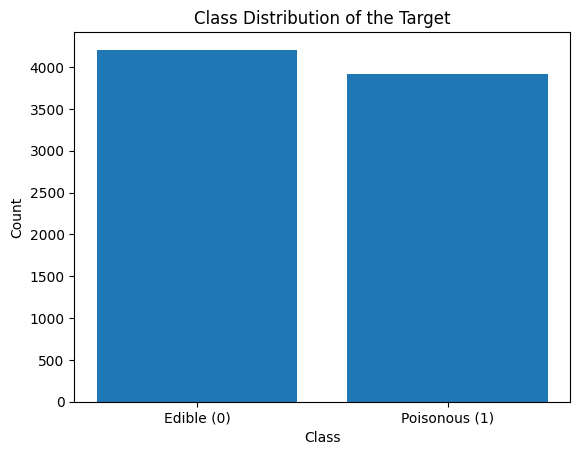

In [ ]:
import matplotlib.pyplot as plt

# Plotting the distribution of the classes in the dataset
plt.bar(['Edible (0)', 'Poisonous (1)'], [len(y[y == 0]), len(y[y == 1])])
plt.title('Class Distribution of the Target')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

Mushroom's target is binary and close to balanced (roughly 52% edible / 48% poisonous) — so accuracy alone is a reasonably trustworthy metric here, without needing to lean as heavily on precision/recall per class.

## 5. Train a Linear Support Vector Classifier

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report

# Initialize a linear SVM
svm_linear = SVC(kernel='linear', random_state=42)

# Train the model
svm_linear.fit(X_train, y_train)

# Predictions on the test set
y_pred = svm_linear.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred, target_names=['Edible', 'Poisonous']))

              precision    recall  f1-score   support

      Edible       1.00      1.00      1.00       632
   Poisonous       1.00      1.00      1.00       587

    accuracy                           1.00      1219
   macro avg       1.00      1.00      1.00      1219
weighted avg       1.00      1.00      1.00      1219



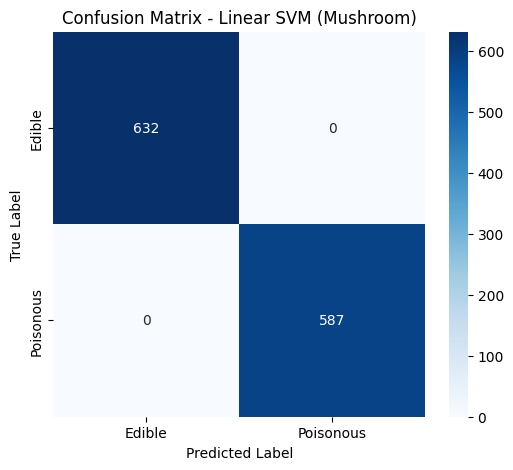

In [ ]:
import seaborn as sns

# Plot confusion matrix as heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt="d", cmap="Blues",
            xticklabels=['Edible', 'Poisonous'],
            yticklabels=['Edible', 'Poisonous'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Linear SVM (Mushroom)')
plt.show()

## 6. Non-Linear SVM on Circles Dataset

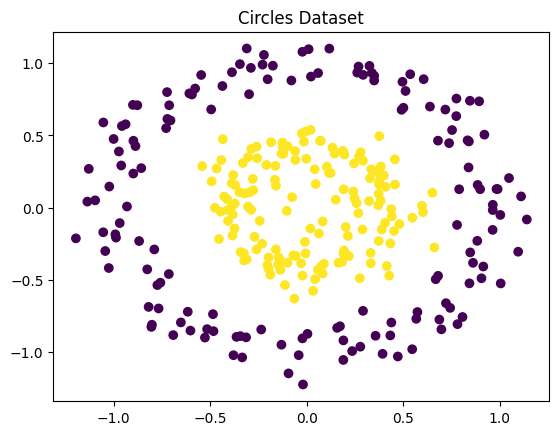

In [ ]:
from sklearn.datasets import make_circles
import numpy as np

# Generate concentric-circles dataset
X_circles, y_circles = make_circles(n_samples=300, noise=0.1, factor=0.4, random_state=42)

# Visualize the dataset
plt.scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, cmap='viridis')
plt.title('Circles Dataset')
plt.show()

## 7. Train SVM with different kernels on Circles Dataset

In [ ]:
# Split the circles dataset into train and test sets
X_train_circles, X_test_circles, y_train_circles, y_test_circles = train_test_split(
    X_circles, y_circles, test_size=0.3, random_state=42
)

In [ ]:
# Train a Linear SVM
svm_linear_circles = SVC(kernel='linear', random_state=42)
svm_linear_circles.fit(X_train_circles, y_train_circles)

# Train a Polynomial Kernel SVM (degree 3)
# degree=2 fits naturally here: a circular boundary is a quadratic (x^2 + y^2 = r^2),
# so a degree-3 kernel actually struggles on this data (try it!) while degree-2 separates it cleanly
svm_poly = SVC(kernel='poly', degree=2, random_state=42)
svm_poly.fit(X_train_circles, y_train_circles)

# Train an RBF Kernel SVM
svm_rbf = SVC(kernel='rbf', random_state=42)
svm_rbf.fit(X_train_circles, y_train_circles)

SVC(random_state=42)

## 8. Visualize Decision Boundaries

In [ ]:
from matplotlib.colors import ListedColormap

def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    # Create mesh grid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.02),
        np.arange(y_min, y_max, 0.02)
    )

    # Predict over the mesh grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot the decision boundary
    cmap_light = ListedColormap(['#FFDDDD', '#DDDDFF'])
    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.6, cmap=cmap_light)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='k')
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

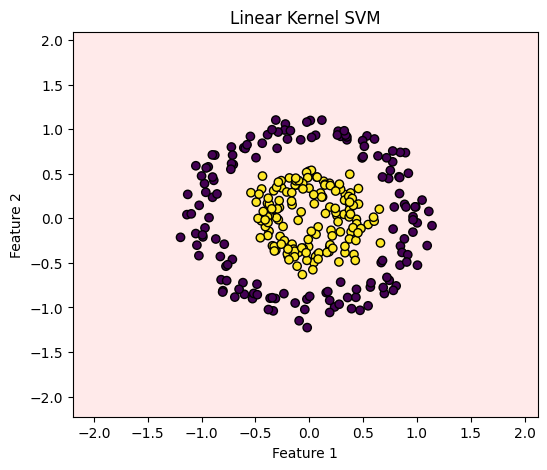

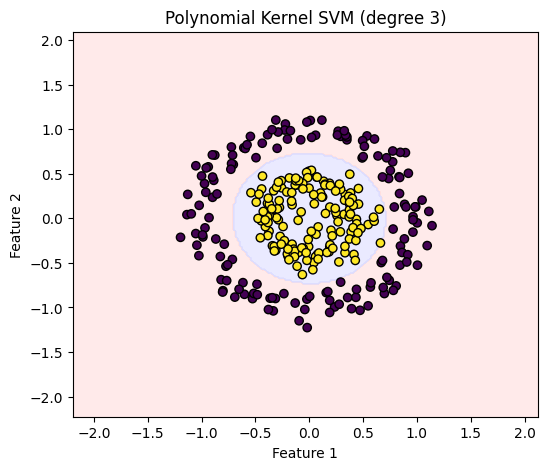

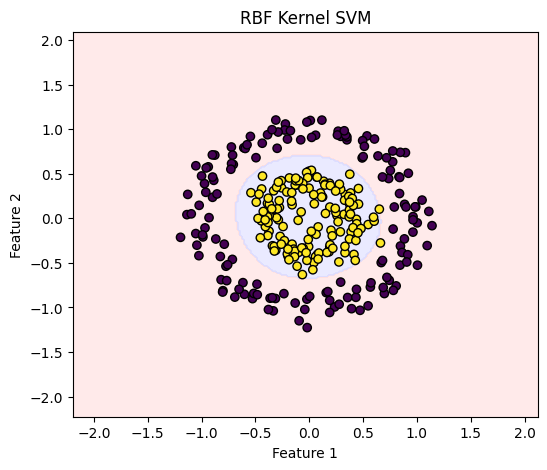

In [ ]:
plot_decision_boundary(svm_linear_circles, X_circles, y_circles, title="Linear Kernel SVM")
plot_decision_boundary(svm_poly, X_circles, y_circles, title="Polynomial Kernel SVM (degree 3)")
plot_decision_boundary(svm_rbf, X_circles, y_circles, title="RBF Kernel SVM")

## 9. Evaluate and Compare Models

In [ ]:
# Evaluate Linear SVM
y_pred_linear_circles = svm_linear_circles.predict(X_test_circles)
print("Linear SVM Classification Report:\n", classification_report(y_test_circles, y_pred_linear_circles))

# Evaluate Polynomial Kernel SVM
y_pred_poly = svm_poly.predict(X_test_circles)
print("Polynomial SVM Classification Report:\n", classification_report(y_test_circles, y_pred_poly))

# Evaluate RBF Kernel SVM
y_pred_rbf = svm_rbf.predict(X_test_circles)
print("RBF SVM Classification Report:\n", classification_report(y_test_circles, y_pred_rbf))

Linear SVM Classification Report:
               precision    recall  f1-score   support

           0       0.42      1.00      0.59        38
           1       0.00      0.00      0.00        52

    accuracy                           0.42        90
   macro avg       0.21      0.50      0.30        90
weighted avg       0.18      0.42      0.25        90

Polynomial SVM Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        38
           1       1.00      1.00      1.00        52

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90

RBF SVM Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        38
           1       1.00      1.00      1.00        52

    accuracy                           1.00        90
   macro avg       1.0

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


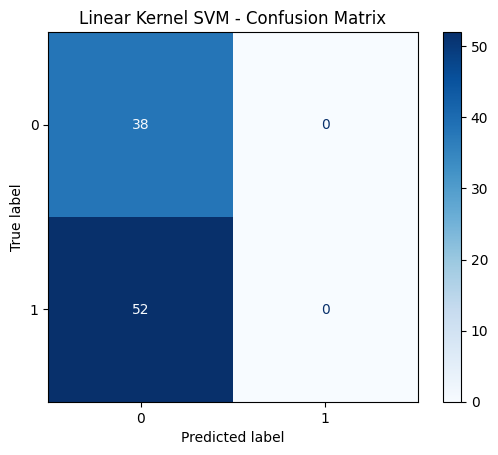

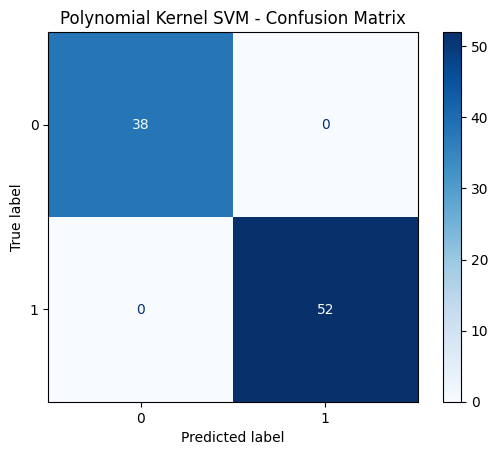

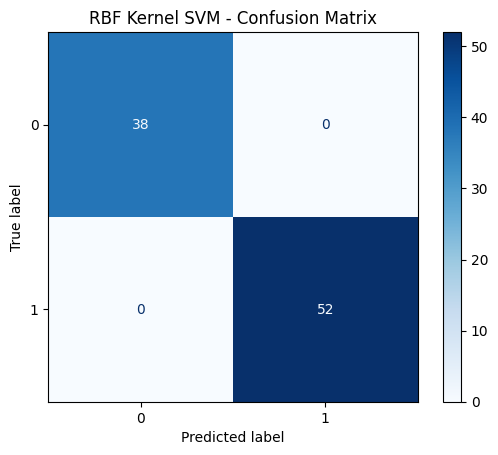

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

# Function to plot confusion matrix
def plot_conf_matrix(model, X_test, y_test, title):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(title)
    plt.show()

plot_conf_matrix(svm_linear_circles, X_test_circles, y_test_circles, "Linear Kernel SVM - Confusion Matrix")
plot_conf_matrix(svm_poly, X_test_circles, y_test_circles, "Polynomial Kernel SVM - Confusion Matrix")
plot_conf_matrix(svm_rbf, X_test_circles, y_test_circles, "RBF Kernel SVM - Confusion Matrix")

On concentric circles, the linear kernel can't separate the classes at all (they're not linearly separable in this feature space), while the polynomial and RBF kernels carve out a circular decision boundary that matches the data's actual structure. Note how sensitive the polynomial kernel is to its `degree` parameter here — degree 2 matches the quadratic circular boundary almost perfectly, but try degree 3 and watch it collapse back to predicting a single class, since an odd-degree homogeneous kernel can't represent a symmetric closed boundary the same way. This is a good moment to connect back to Mushroom above: since we one-hot encoded all 22 categorical features into a very high-dimensional binary space, a linear kernel there was already reasonably expressive — but for a low-dimensional problem with genuinely non-linear structure like this, kernel choice (and its hyperparameters) matters a lot more.

#Assignment 7 : SVM Regressor

##### <font color='pink'>**A quick note on SVR:**
Support Vector Regression extends the same margin-based idea from SVM classification to continuous targets. Instead of maximizing the margin between classes, SVR fits a function within an **ε-insensitive tube** around the data — predictions within ε of the true value incur zero loss, and only points *outside* the tube contribute to the loss, weighted by C:$$f(x) = \sum_i (\alpha_i - \alpha_i^*)\, K(x_i, x) + b$$where $K$ is the kernel (linear: $K(x,x')=x \cdot x'$; RBF: $K(x,x')=\exp(-\gamma\|x-x'\|^2)$). $C$ controls the trade-off between a flatter/simpler function and tolerating fewer points outside the tube (larger $C$ → less tolerance, tighter fit to training data); $\varepsilon$ controls how wide that zero-loss tube is (larger $\varepsilon$ → more tolerance for small errors, but potentially more bias). $\gamma$ (RBF only) controls how far each training point's influence reaches, same role as in SVC.

### <font color='pink'>A Quick Look at the Kernel Trick
Many algorithms, including SVMs, only ever need to compute **dot products** between data points — never the points themselves. The kernel trick exploits this: instead of explicitly transforming data into a higher-dimensional space where it becomes linearly separable, we compute a kernel function $K(x, x')$ that equals the dot product of the transformed points, *without ever computing the transformation itself*.**A concrete toy example.** Take 2D points $x = (x_1, x_2)$, and define the mapping $\varphi(x) = (x_1^2,\ \sqrt{2}\,x_1 x_2,\ x_2^2)$, lifting each point into 3D. It turns out that:$$\varphi(x) \cdot \varphi(x') = (x_1 x_1' + x_2 x_2')^2 = (x \cdot x')^2$$So instead of explicitly computing $\varphi(x)$ and $\varphi(x')$ (3 numbers each) and then their dot product, we can just compute $(x \cdot x')^2$ directly on the original 2D points — this *is* the polynomial kernel of degree 2. Same result, far less computation, and the trick scales to spaces with far more dimensions (even infinite, as with the RBF kernel) where explicitly computing $\varphi(x)$ wouldn't be feasible at all.

Task-0 (ungraded):Pick any two 2D points $x = (x_1, x_2)$ and $x' = (x_1', x_2')$. Write code to:(a) Compute $\varphi(x)$ and $\varphi(x')$ explicitly using the mapping above, then take their dot product.(b) Compute $(x \cdot x')^2$ directly on the original points.Confirm both give the same result.

Task-1: [1 marks]1.1. Load the [Energy Efficiency dataset](https://archive.ics.uci.edu/dataset/242/energy+efficiency) from UCI. Use `Y1` (Heating Load) as the regression target. [0.5 marks]1.2. Split the dataset into training, validation and test sets (70%-15%-15%). [0.5 marks]

Task-2: [2 marks]2.1. Perform feature scaling such that the features lie in the same range of values. [1 marks]2.2. Show the correlation between the features of the training set. [1 marks]

Task-3: [5 marks]3.1. Fit an SVM with linear kernel on the training set using sklearn's SVR. [2 marks]3.2. Tune the hyperparameters C and ε on the validation set using grid search (Take range of values of C and ε as provided below). [3 marks]C = 0.01, 0.1, 1, 10, 100; ε = 0.001, 0.01, 0.1, 0.5, 1.0

Task-4: [3 marks]4.1. Evaluate the linear SVM regressor using the best value of C and ε you obtained. Report the performance in terms of MSE and R^2 score. [1 marks]4.2. Show a scatter plot of the predictions of the linear SVR model vs. the ground truth target values. [2 marks]

Task-5: [6 marks]5.1. Fit an SVM with RBF kernel on the training set using sklearn's SVR. [2 marks]5.2. Tune the hyperparameters C, γ and ε on the validation set using grid search (Take range of values of C, γ and ε as provided below). [4 marks]C = 0.1, 1, 10, 100, 1000; γ = 0.001, 0.01, 0.1, 1, 10; ε = 0.01, 0.1, 0.5, 1.0

Task-6: [3 marks]6.1. Evaluate the RBF SVM regressor using the best value of C, γ and ε you obtained. Report the performance in terms of MSE and R^2 score. [1 marks]6.2. Show a scatter plot of the predictions of the RBF SVR model vs. the ground truth target values. [2 marks]